### 📂 Dataset Selection

| Metric / Parameter | Value |
| :--- | :--- |
| **Dataset Name** | Breast Cancer Dataset |
| **Source** | Kaggle |
| **URL** | [Kaggle Dataset Link](https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset/data) |
| **Number of Observations** | 569 |
| **Number of Features** | 30 |
| **Target Variable (y)** | `diagnosis` (Malignant = 1, Benign = 0) |

#### **Features (X) Included in the Model:**
The dataset contains the mean, standard error (se), and "worst" (mean of the three largest values) measurements for 10 core real-valued features:
* **Cell Nucleus Shape & Size:** `radius`, `texture`, `perimeter`, `area`, `smoothness`
* **Cell Nucleus Structure:** `compactness`, `concavity`, `concave points`, `symmetry`, `fractal_dimension`


# IMPORTING REQUIRED LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# IMPORTING DATASET

In [2]:
df = pd.read_csv('Breast_cancer_dataset.csv')

In [3]:
df.drop(columns=['Unnamed: 32', 'id'], inplace=True)

df['diagnosis'] = df['diagnosis'].map({'M' : 1, "B" : 0})

In [4]:
X = df.drop(columns='diagnosis')
y = df['diagnosis']

# TRAIN-TEST-SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TRAIN LOGISTIC REGRESSION MODEL

In [7]:
LR = LogisticRegression()

LR.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# PREDICT VALUES

In [8]:
LR_y_pred = LR.predict(X_test_scaled)

# EVALUATE

In [9]:
LR_accuracy = accuracy_score(y_test, LR_y_pred)
LR_precision = precision_score(y_test, LR_y_pred)
LR_recall = recall_score(y_test, LR_y_pred)
LR_f1_score = f1_score(y_test, LR_y_pred)

print('Accuarcy Score :', LR_accuracy)
print('Precision Score :', LR_precision)
print('Recall Score :', LR_recall)
print('F1 Score :', LR_f1_score)

Accuarcy Score : 0.9736842105263158
Precision Score : 0.9761904761904762
Recall Score : 0.9534883720930233
F1 Score : 0.9647058823529412


# CONFUSION MATRIX

<Axes: >

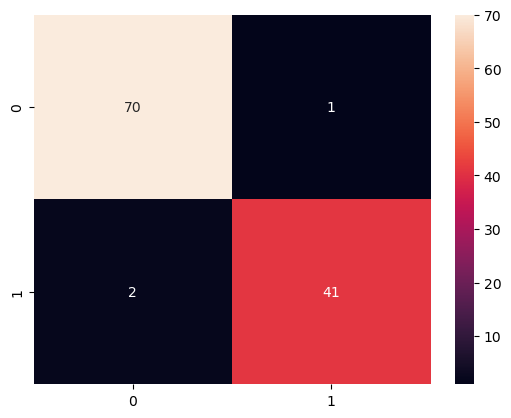

In [10]:
sns.heatmap(confusion_matrix(y_test, LR_y_pred), annot=True)

In [11]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100], "tol": [1e-4, 1e-5, 1e-3]}

# TRAIN LOGISTIC REGRESSION WITH L2 PENALTY / RIDGE LOGISTIC REGRESSION

In [12]:
ridge = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=10000, random_state=42)

grid_ridge = GridSearchCV(
    estimator=ridge, param_grid=param_grid, cv=5, scoring="accuracy"
)

grid_ridge.fit(X_train_scaled, y_train)
pred_ridge = grid_ridge.predict(X_test_scaled)

print(f"Ridge - Best Parameters: {grid_ridge.best_params_}")
print(f"Ridge - Best CV Score: {grid_ridge.best_score_:.4f}\n")

Ridge - Best Parameters: {'C': 1, 'tol': 0.001}
Ridge - Best CV Score: 0.9758



In [13]:
ridge = LogisticRegression(penalty="l2", solver="lbfgs", C=1, tol=0.001, random_state=42)

ridge.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# PREDICT VALUES

In [14]:
y_pred_ridge = ridge.predict(X_test_scaled)

# EVALUATE

In [15]:
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
precision_ridge = precision_score(y_test, y_pred_ridge)
recall_ridge = recall_score(y_test, y_pred_ridge)
f1_score_ridge = f1_score(y_test, y_pred_ridge)

print('Accuarcy Score :', accuracy_ridge)
print('Precision Score :', precision_ridge)
print('Recall Score :', recall_ridge)
print('F1 Score :', f1_score_ridge)

Accuarcy Score : 0.9824561403508771
Precision Score : 0.9767441860465116
Recall Score : 0.9767441860465116
F1 Score : 0.9767441860465116


# CONFUSION MATRIX

<Axes: >

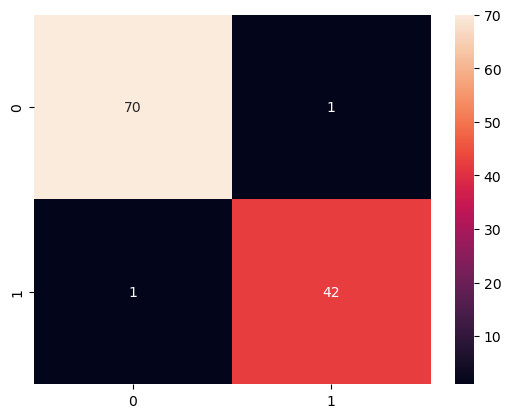

In [16]:
sns.heatmap(confusion_matrix(y_test, y_pred_ridge), annot=True)

# TRAIN LOGISTIC REGRESSION WITH L1 PENALTY / LASSO LOGISTIC REGRESSION

In [17]:
lasso = LogisticRegression(
    penalty="l1", solver="liblinear", max_iter=10000, random_state=42
)

grid_lasso = GridSearchCV(
    estimator=lasso, param_grid=param_grid, cv=5, scoring="accuracy"
)

grid_lasso.fit(X_train_scaled, y_train)
pred_lasso = grid_lasso.predict(X_test_scaled)

print(f"Lasso - Best Parameters: {grid_lasso.best_params_}")
print(f"Lasso - Best CV Score: {grid_lasso.best_score_:.4f}\n")

Lasso - Best Parameters: {'C': 1, 'tol': 1e-05}
Lasso - Best CV Score: 0.9780



In [18]:
lasso = LogisticRegression(penalty="l1", solver="liblinear", C=1.0, tol=1e-05 ,random_state=42)

lasso.fit(X_train_scaled, y_train)

,penalty,'l1'
,dual,False
,tol,1e-05
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


# PREDICT VALUES

In [19]:
y_pred_lasso = lasso.predict(X_test_scaled)

# EVALUATE

In [20]:
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
precision_lasso = precision_score(y_test, y_pred_lasso)
recall_lasso = recall_score(y_test, y_pred_lasso)
f1_score_lasso = f1_score(y_test, y_pred_lasso)

print('Accuarcy Score :', accuracy_lasso)
print('Precision Score :', precision_lasso)
print('Recall Score :', recall_lasso)
print('F1 Score :', f1_score_lasso)

Accuarcy Score : 0.9736842105263158
Precision Score : 0.9545454545454546
Recall Score : 0.9767441860465116
F1 Score : 0.9655172413793104


# CONFUSION MATRIX

<Axes: >

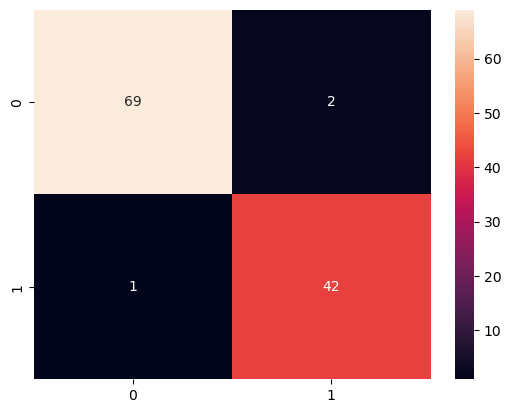

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred_lasso), annot=True)

# Building the Machine Learning Pipeline

In [22]:
best_ridge_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),  
        (
            "ridge_classifier",
            LogisticRegression(
                penalty="l2", solver="lbfgs", C=1, tol=0.001, max_iter=10000, random_state=42,
            ),
        ),
    ]
)

# Training the Pipeline Model

In [23]:
best_ridge_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('ridge_classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.001
,C,1


# PREDICTION USING Pipeline MODEL

In [24]:
y_pred_final = best_ridge_pipeline.predict(X_test)

In [25]:
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_score_final = f1_score(y_test, y_pred_final)

print('Accuarcy Score :', accuracy_final)
print('Precision Score :', precision_final)
print('Recall Score :', recall_final)
print('F1 Score :', f1_score_final)

Accuarcy Score : 0.9824561403508771
Precision Score : 0.9767441860465116
Recall Score : 0.9767441860465116
F1 Score : 0.9767441860465116


# CONFUSION MATRIX

<Axes: >

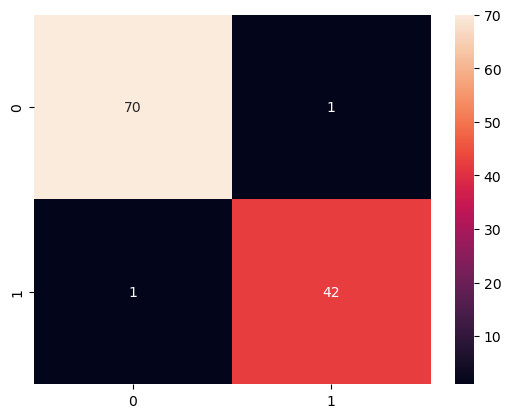

In [26]:
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True)

### 📊 Classification Model Comparison

| Model | Best Parameters | Accuracy | Precision | Recall | F1-Score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | N/A | 0.9737 | 0.9762 | 0.9535 | 0.9647 |
| **Ridge Logistic Regression** | `{'C': 1, 'tol': 0.001}` | **0.9825** | **0.9767** | **0.9767** | **0.9767** |
| **Lasso Logistic Regression** | `{'C': 1, 'tol': 1e-05}` | 0.9737 | 0.9762 | 0.9535 | 0.9647 |

## Question 1: Which model achieved the highest accuracy, precision, recall, and F1-score? Which model performed best overall?

Answer: Ridge Logistic Regression achieved the highest performance across all evaluation metrics. It scored 0.9825 in Accuracy, and a matching 0.9767 across Precision, Recall, and F1-Score. Consequently, Ridge Logistic Regression performed best overall, presenting the most balanced and accurate generalization on the test dataset.

## Question 2: Did GridSearchCV improve the regularized models?

Answer: Yes, GridSearchCV successfully improved the Ridge Logistic Regression model. While the baseline, unregularized Logistic Regression model yielded a strong accuracy of 0.9737, hyperparameter tuning via GridSearchCV discovered an optimal regularization blend (C: 1, tol: 0.001). Applying this L2 penalty minimized overfitting by preventing feature weights from inflating. This optimization resulted in a 0.88% increase in overall Accuracy and successfully pushed Recall up from 0.9535 to 0.9767.(Note: For the Lasso model, GridSearchCV selected parameters that mirrored the default baseline settings, resulting in identical metrics to standard Logistic Regression).

## Question 3: Explain and interpret the confusion matrix of the best model

The confusion matrix for the top-performing model (Ridge Logistic Regression) details exactly how the 114 test instances were mapped:True Negatives (TN) = 70: The model correctly predicted 70 patients as "Benign" (Class 0) who were safely healthy.True Positives (TP) = 42: The model correctly diagnosed 42 patients as "Malignant" (Class 1) who genuinely had breast cancer.False Positives (FP) = 1: The model committed only 1 Type I error, mistakenly flagging a benign patient as malignant. This minimal margin of error directly yields the outstanding 0.9767 Precision score.False Negatives (FN) = 1: The model committed only 1 Type II error, failing to catch a single malignant case. Minimizing False Negatives is the most critical metric in medical diagnostic models to avoid leaving sick patients untreated. This translates to an excellent 0.9767 Recall rate.

# Conclusion

Out of 114 total diagnostic test cases, the Ridge model made a correct assessment for 112 patients, making it a highly reliable and balanced clinical classifier for this dataset.